In [117]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [118]:
OPTIONS = json.loads(open('../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'variable': 'wz', 'test': 1, 'limits': [15, 999]}

In [119]:
TARGET_VAR = OPTIONS.get('variable')
TEST_VAR   = OPTIONS.get('test')

TARGET_TIME = tuple(OPTIONS.get('limits'))
VIEW_LIMITS = (0.2, 0.6)

# DADOS

In [120]:
df = pd.read_csv(f'files/test_{TEST_VAR}_{TARGET_VAR}.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,q0,ay,q1,q3,q2,wy,pitch,roll,yaw,wz,wx,ax,time,sample_time,la_pos_mon_d,az
0,1.0000,-9.791,-0.001727,-0.001732,-0.000230,-0.000388,-0.000465,-0.003452,-0.003464,-0.003721,-0.000869,-0.3770,0.000000,105000000.0,0.0,0.15670
1,1.0000,-9.774,-0.001798,-0.001785,-0.000237,-0.001582,-0.000477,-0.003593,-0.003567,0.001437,-0.001299,-0.3264,0.096150,205000000.0,0.0,0.15370
2,1.0000,-9.779,-0.001621,-0.001472,-0.000288,-0.000148,-0.000580,-0.003239,-0.002941,0.006575,0.004907,-0.3381,0.191993,305000000.0,0.0,0.14800
3,1.0000,-9.785,-0.001652,-0.001348,-0.000252,0.002097,-0.000507,-0.003303,-0.002693,0.000795,-0.002183,-0.3709,0.287721,405000000.0,0.0,0.15710
4,1.0000,-9.784,-0.001600,-0.001333,-0.000136,0.002190,-0.000275,-0.003197,-0.002662,0.000846,0.002001,-0.3752,0.390934,505000000.0,0.0,0.16400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,0.6862,-9.772,0.699700,-0.194100,-0.043430,-0.001741,0.213600,1.553000,-0.341300,0.001742,0.002567,0.5107,149.696933,805000000.0,10.0,-0.08408
1498,0.6862,-9.780,0.699700,-0.194000,-0.043620,-0.001765,0.213300,1.553000,-0.341500,0.005207,0.002494,0.4834,149.791605,905000000.0,10.0,-0.07341
1499,0.6860,-9.777,0.699800,-0.194100,-0.043860,-0.005902,0.213100,1.554000,-0.341900,0.000624,0.002790,0.4994,149.904933,5000000.0,10.0,-0.07292
1500,0.6859,-9.777,0.699900,-0.194300,-0.044150,-0.006546,0.213000,1.554000,-0.342600,-0.000538,0.003760,0.4787,149.999556,105000000.0,10.0,-0.07352


- Convertendo pra radianos

In [121]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,q0,ay,q1,q3,q2,wy,pitch,roll,yaw,wz,wx,ax,time,sample_time,la_pos_mon_d,az
0,1.0000,-9.791,-0.001727,-0.001732,-0.000230,-0.022254,-0.026660,-0.197785,-0.198473,-0.213198,-0.049767,-0.3770,0.000000,105000000.0,0.0,0.15670
1,1.0000,-9.774,-0.001798,-0.001785,-0.000237,-0.090642,-0.027313,-0.205864,-0.204374,0.082334,-0.074427,-0.3264,0.096150,205000000.0,0.0,0.15370
2,1.0000,-9.779,-0.001621,-0.001472,-0.000288,-0.008451,-0.033214,-0.185581,-0.168507,0.376720,0.281150,-0.3381,0.191993,305000000.0,0.0,0.14800
3,1.0000,-9.785,-0.001652,-0.001348,-0.000252,0.120149,-0.029060,-0.189248,-0.154298,0.045562,-0.125077,-0.3709,0.287721,405000000.0,0.0,0.15710
4,1.0000,-9.784,-0.001600,-0.001333,-0.000136,0.125478,-0.015733,-0.183175,-0.152521,0.048478,0.114649,-0.3752,0.390934,505000000.0,0.0,0.16400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,0.6862,-9.772,0.699700,-0.194100,-0.043430,-0.099752,12.238379,88.980346,-19.555050,0.099809,0.147078,0.5107,149.696933,805000000.0,10.0,-0.08408
1498,0.6862,-9.780,0.699700,-0.194000,-0.043620,-0.101127,12.221190,88.980346,-19.566509,0.298339,0.142896,0.4834,149.791605,905000000.0,10.0,-0.07341
1499,0.6860,-9.777,0.699800,-0.194100,-0.043860,-0.338160,12.209731,89.037641,-19.589427,0.035753,0.159855,0.4994,149.904933,5000000.0,10.0,-0.07292
1500,0.6859,-9.777,0.699900,-0.194300,-0.044150,-0.375058,12.204001,89.037641,-19.629534,-0.030808,0.215432,0.4787,149.999556,105000000.0,10.0,-0.07352


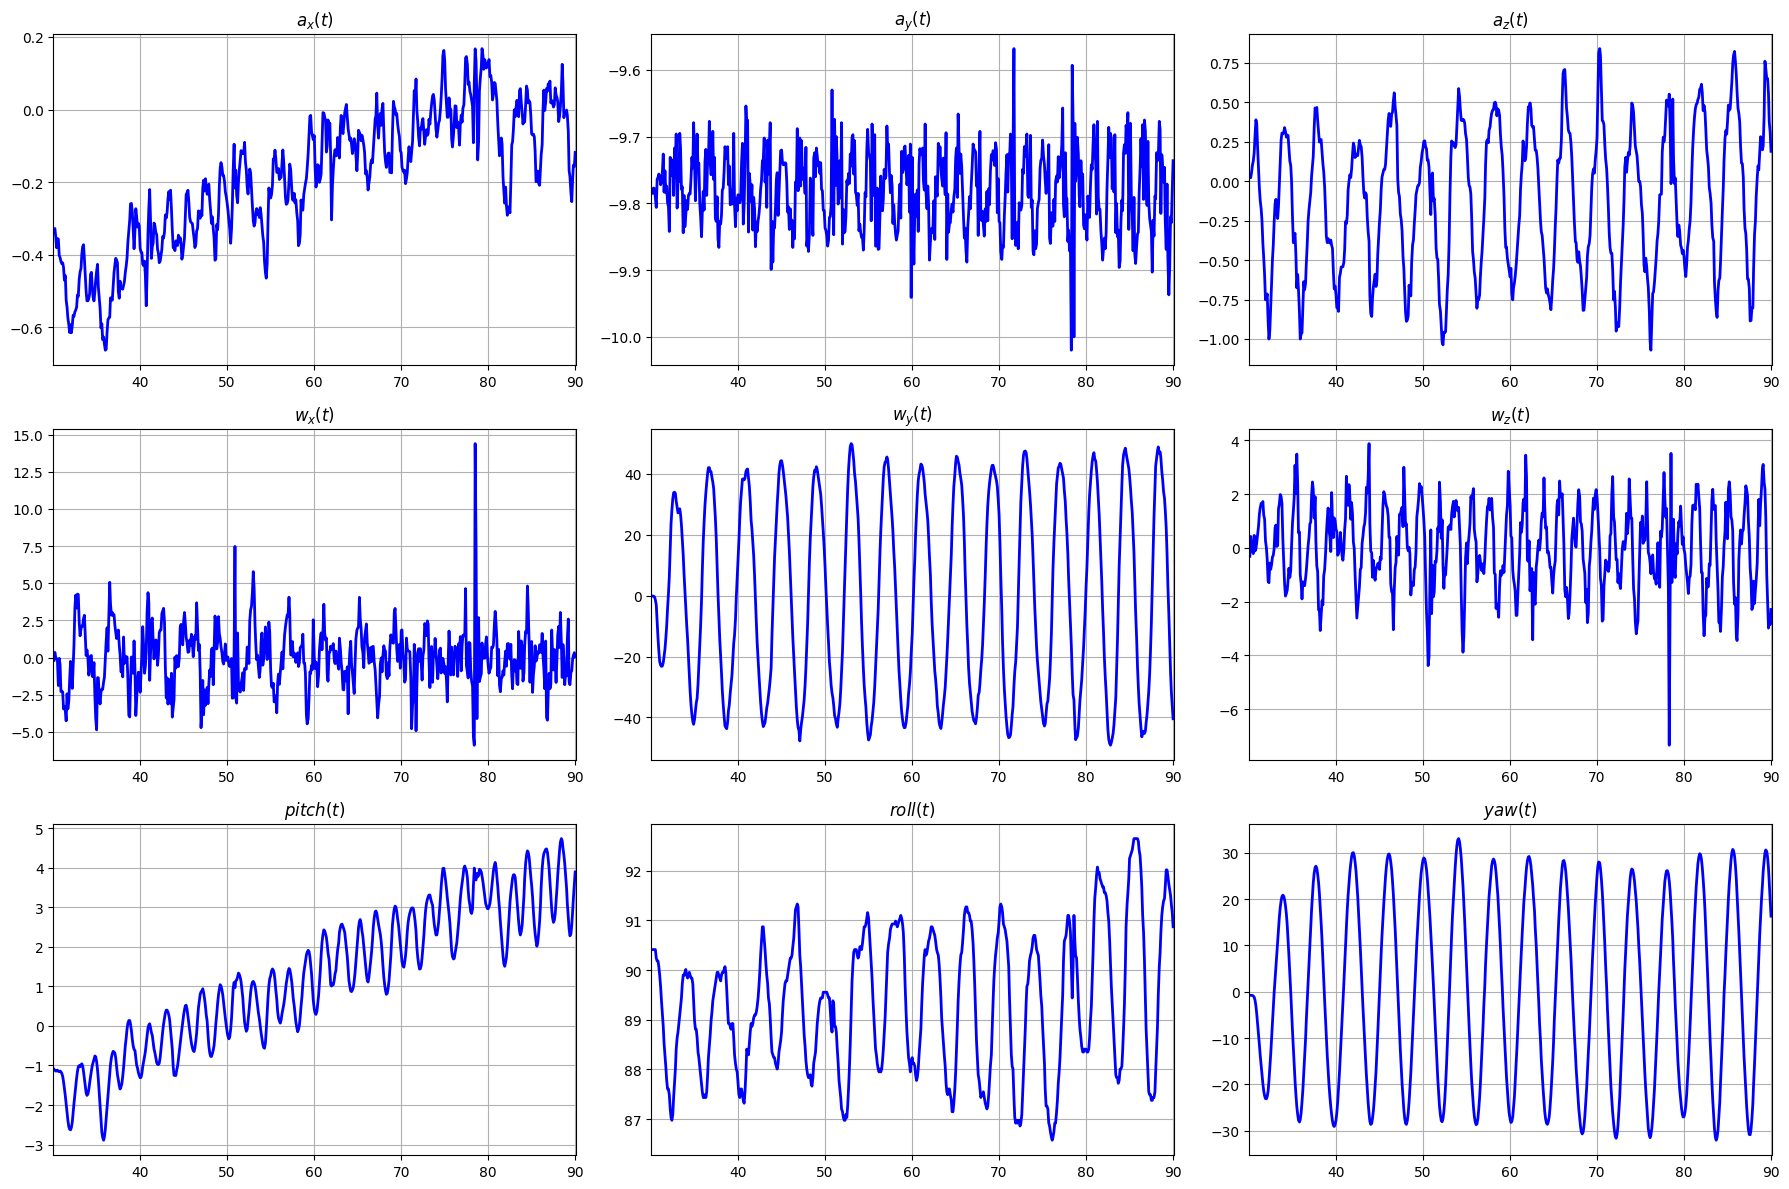

In [122]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, VIEW_LIMITS)

# FILTRANDO POR VARIAVEL

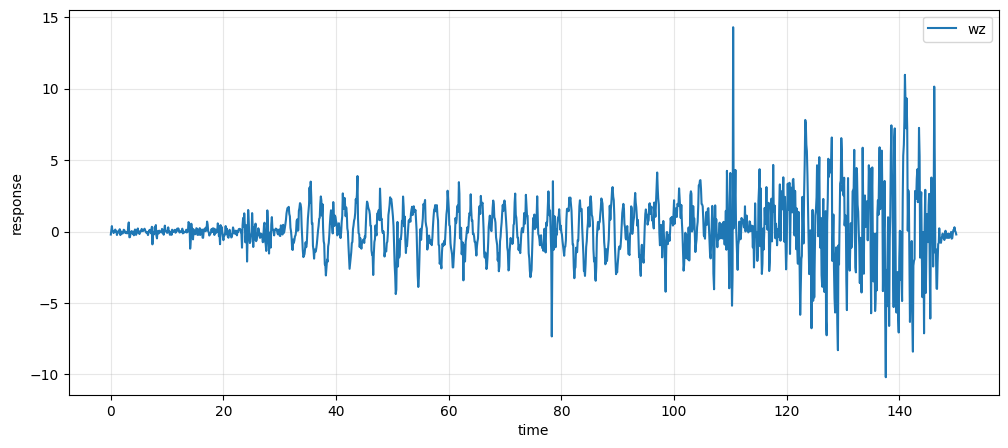

In [123]:
plt.figure(figsize=(12, 5))
plt.plot(df.time, df[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

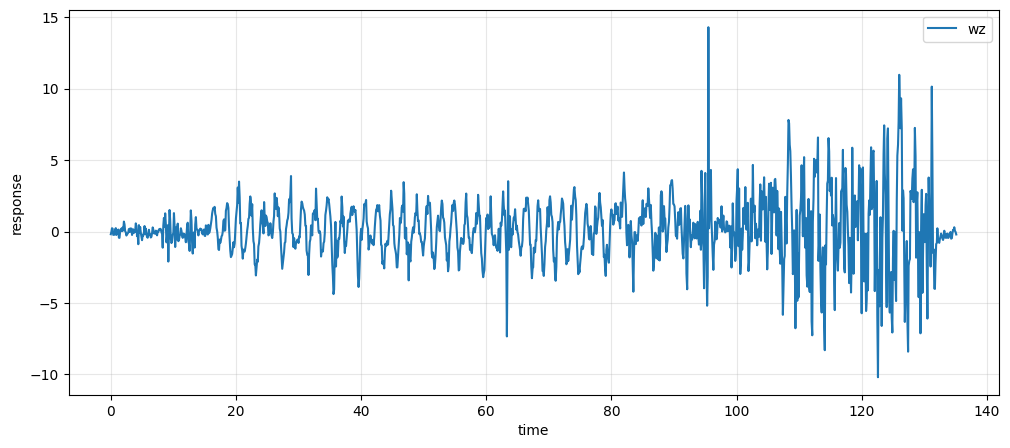

In [124]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

plt.figure(figsize=(12, 5))
plt.plot(df.time, df[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

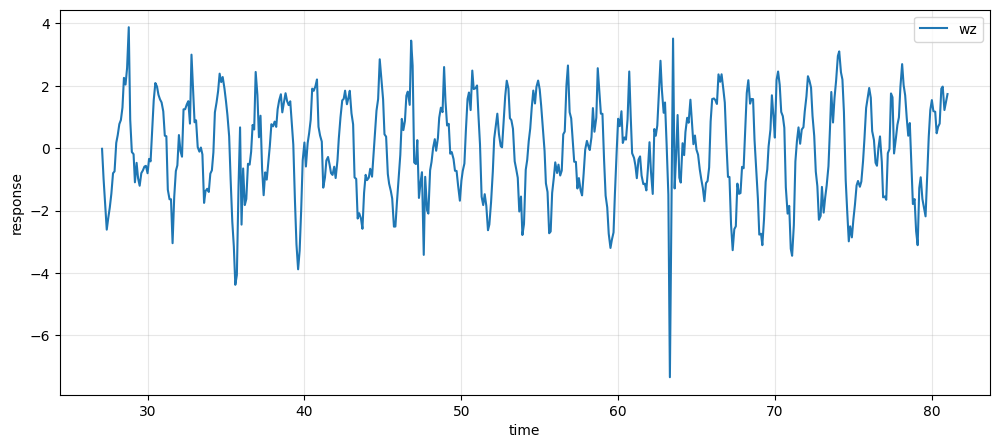

In [125]:
VIEW_TIME = (df.time.values[-1]*VIEW_LIMITS[0], df.time.values[-1]*VIEW_LIMITS[1])
target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

plt.figure(figsize=(12, 5))
plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

In [126]:
df = df.rename(columns={col: 'kongsberg_' + col for col in df.columns if col != 'time'})
df

,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,time,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az
150,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.3497,0.000000,105000000.0,-0.02016,0.15330
151,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.3400,0.098466,205000000.0,-0.02187,0.12410
152,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.3360,0.191033,305000000.0,-0.02364,0.10510
153,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.3610,0.295896,405000000.0,-0.02549,0.10260
154,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.3827,0.389251,505000000.0,-0.02747,0.10320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,0.6862,-9.772,0.6997,-0.19410,-0.04343,-0.099752,12.238379,88.980346,-19.555050,0.099809,0.147078,0.5107,134.696582,805000000.0,10.00000,-0.08408
1498,0.6862,-9.780,0.6997,-0.19400,-0.04362,-0.101127,12.221190,88.980346,-19.566509,0.298339,0.142896,0.4834,134.791253,905000000.0,10.00000,-0.07341
1499,0.6860,-9.777,0.6998,-0.19410,-0.04386,-0.338160,12.209731,89.037641,-19.589427,0.035753,0.159855,0.4994,134.904581,5000000.0,10.00000,-0.07292
1500,0.6859,-9.777,0.6999,-0.19430,-0.04415,-0.375058,12.204001,89.037641,-19.629534,-0.030808,0.215432,0.4787,134.999204,105000000.0,10.00000,-0.07352


In [127]:
df.to_csv('DataBase.csv', index=None)